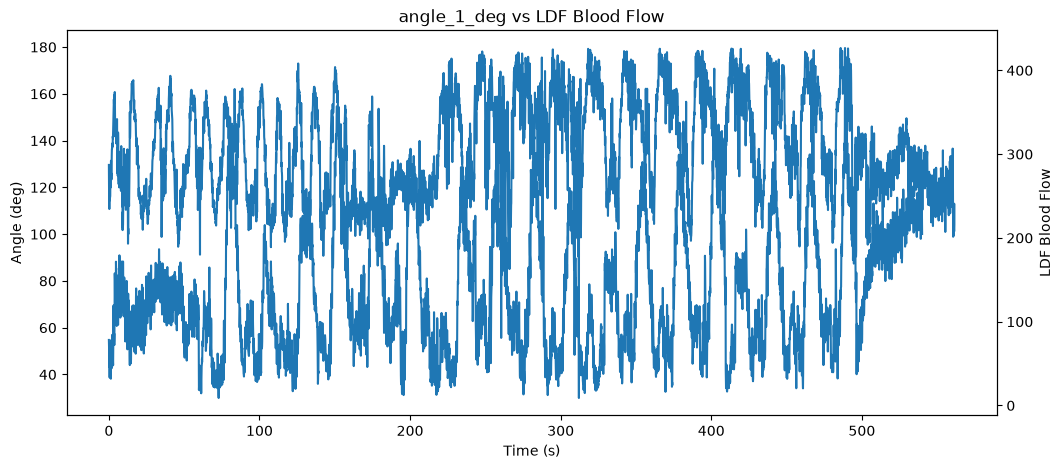

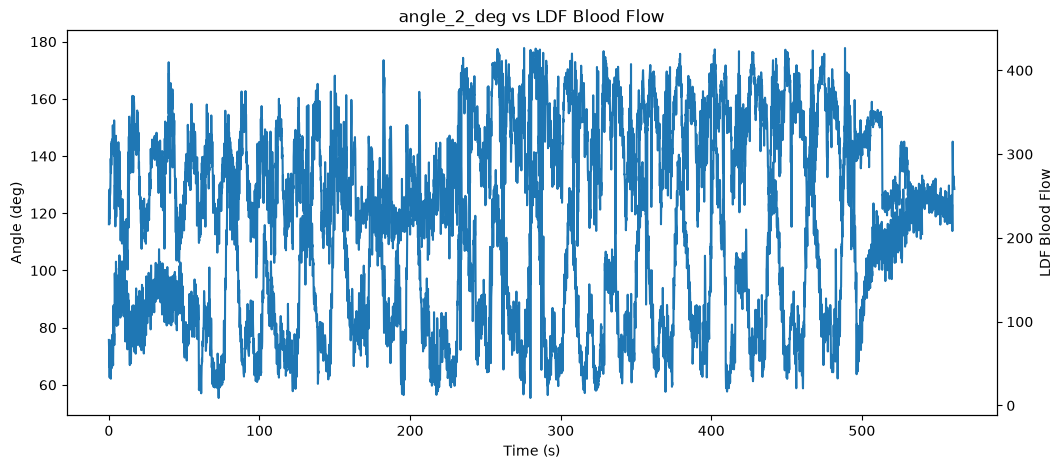

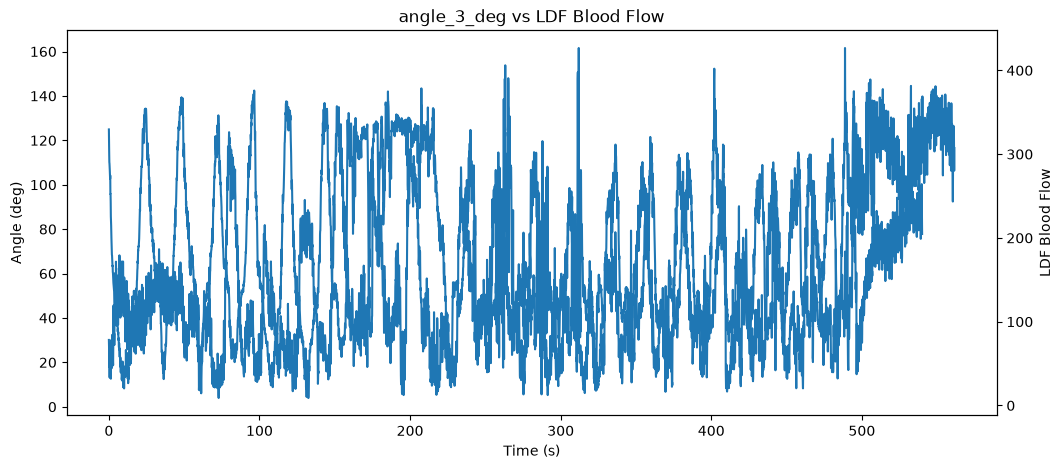

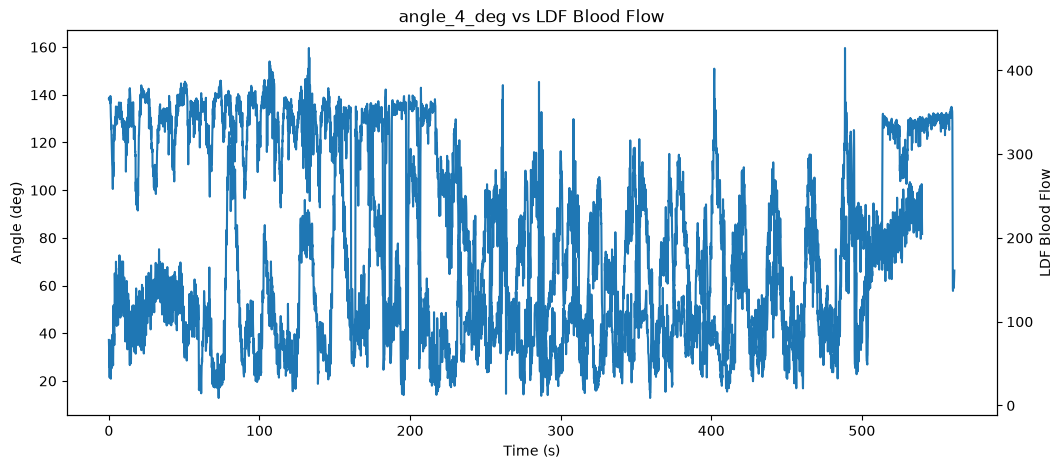

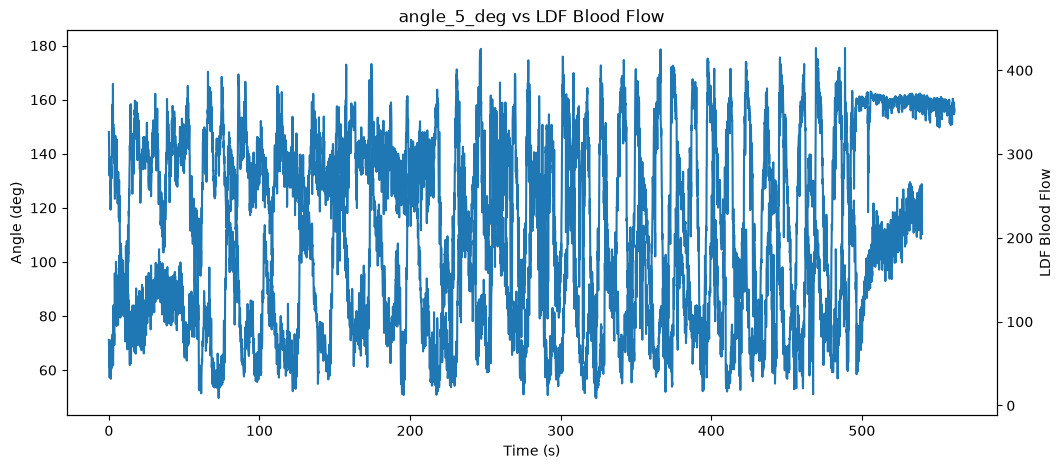

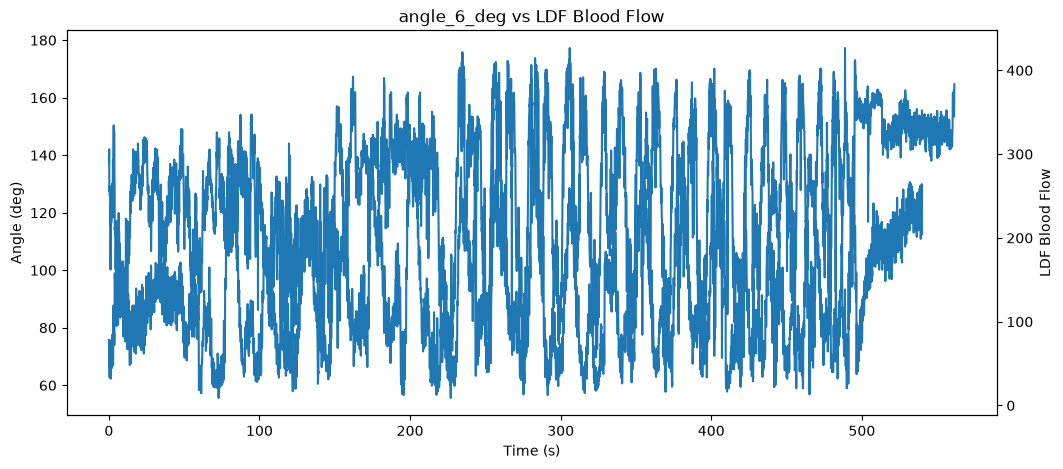

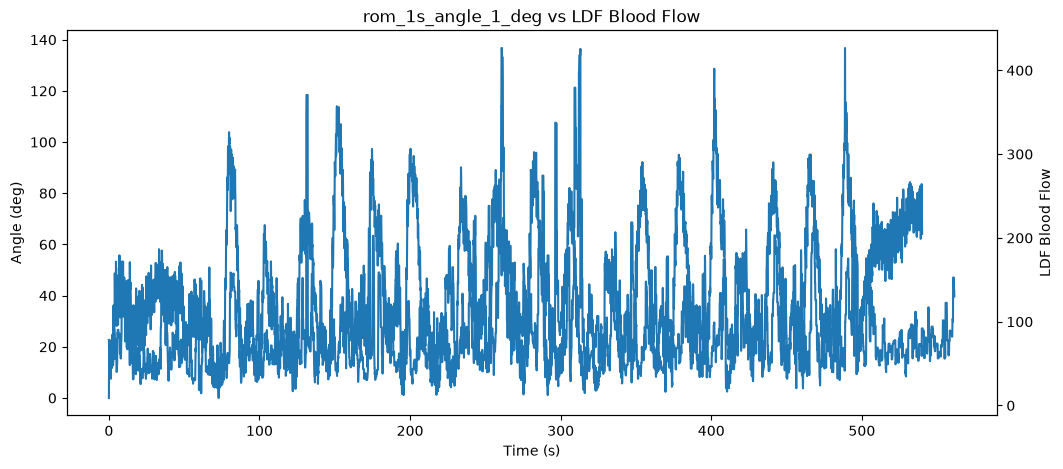

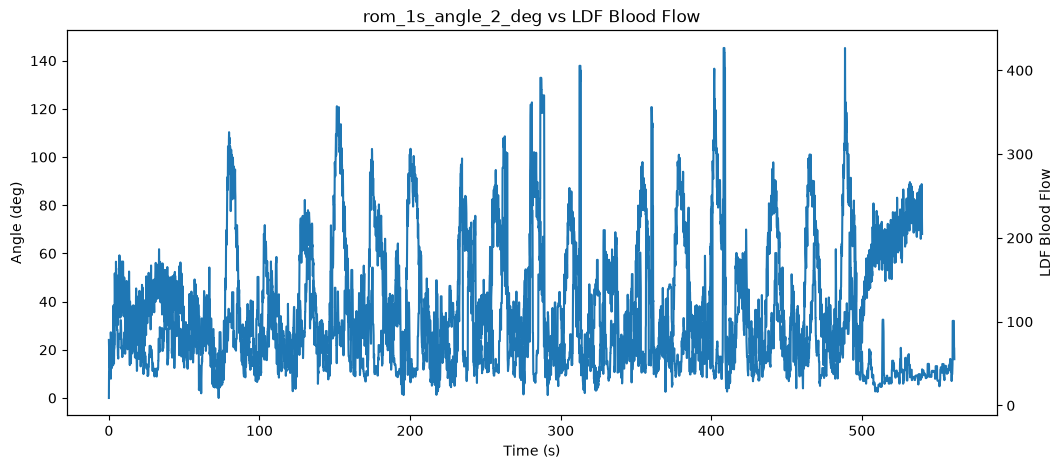

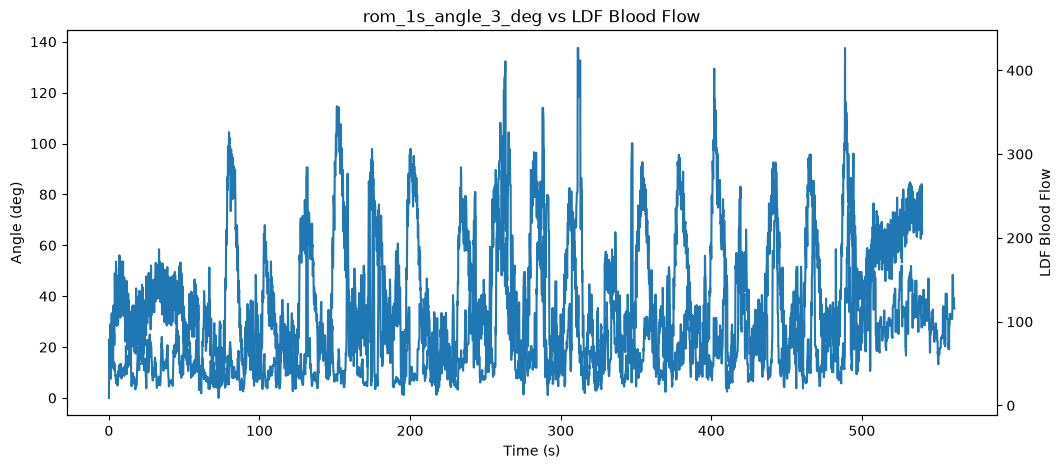

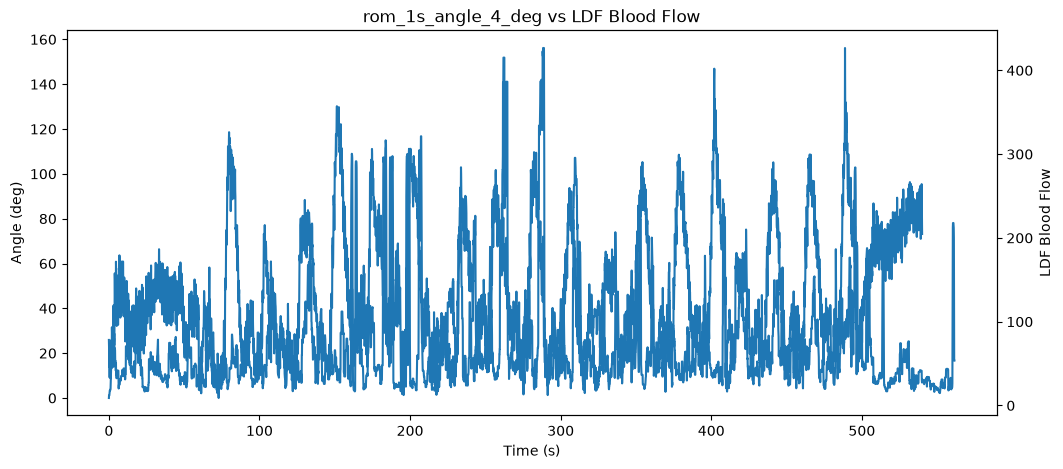

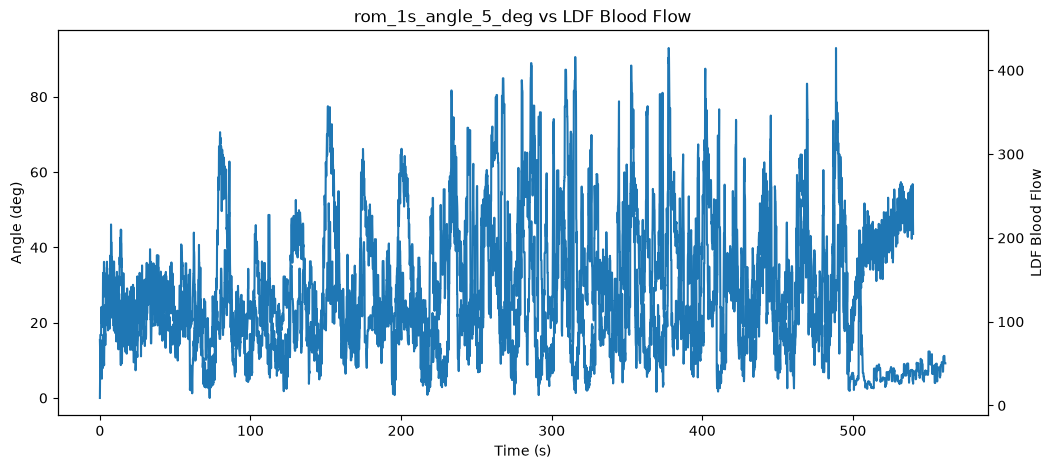

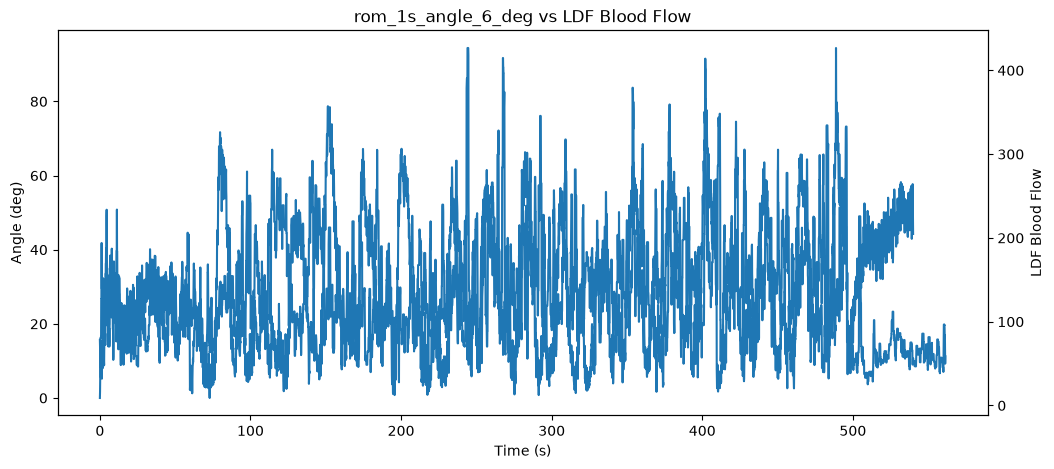

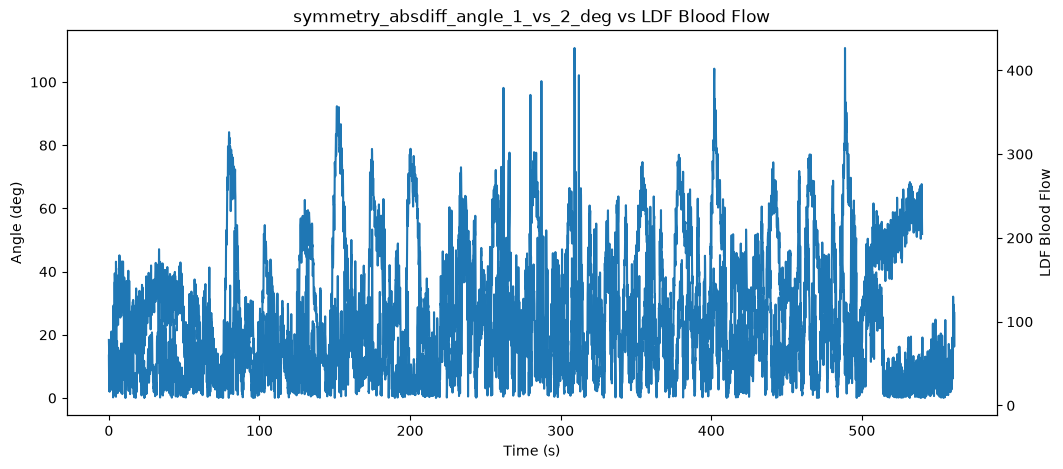

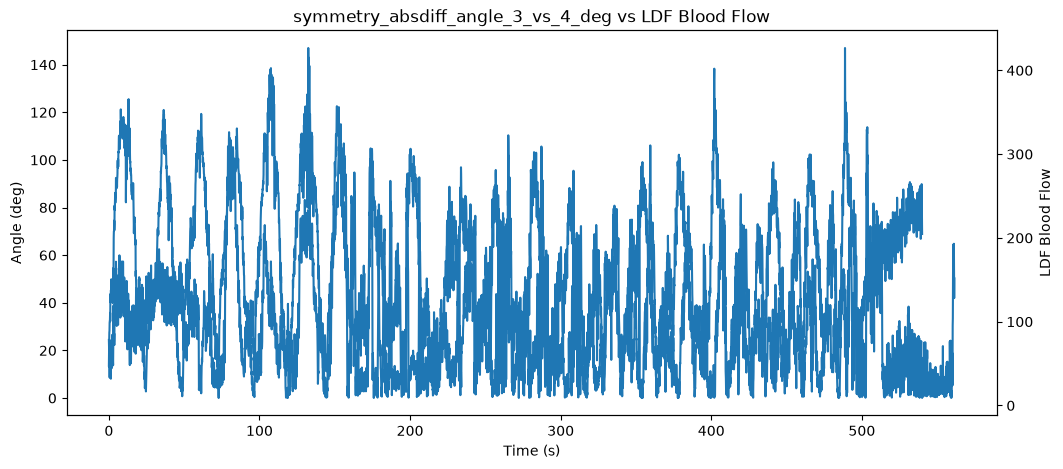

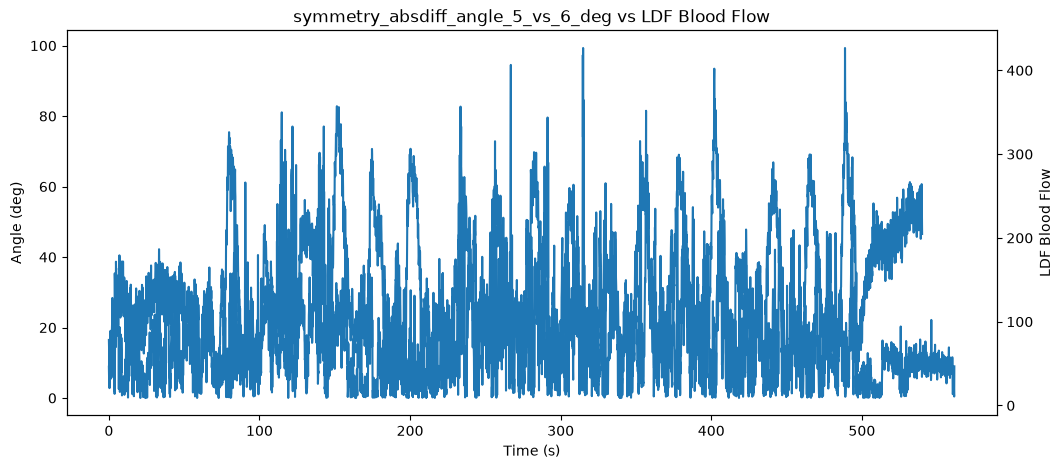

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("combined_data.csv", index_col=0)

angle_cols = [col for col in df.columns if "angle_" in col and "_deg" in col]

for angle in angle_cols:

    fig, ax1 = plt.subplots(figsize=(12,5))

    ax1.plot(df["time_sec"], df[angle], label=angle)
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Angle (deg)")

    ax2 = ax1.twinx()
    ax2.plot(df["time_sec"], df["LDF_bloodflow"])
    ax2.set_ylabel("LDF Blood Flow")

    plt.title(f"{angle} vs LDF Blood Flow")
    plt.show()

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

df = pd.read_csv("combined_data.csv", index_col=0)

# remove missing values
df = df.dropna()

X = df.drop(columns=["LDF_bloodflow"])
y = df["LDF_bloodflow"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

MAE: 64.28795972222223
R2: -0.13293845004137927
